# CICIoT2023 — tạo các tập train 100k, 500k và 1 triệu dòng trên Kaggle

**Phạm vi:** chuẩn bị dữ liệu cho TV1-02/TV1-03 và bàn giao cho người huấn luyện. Bài toán gồm đúng 8 lớp: Normal, BruteForce, DDoS, DoS, Mirai, Recon, Spoofing, Web-Based.

Notebook lấy mẫu từ bộ **đã preprocessing**, giữ toàn bộ BruteForce/Web-Based và lấy mẫu không hoàn lại từ các lớp khác. Ba tập lồng nhau theo **chỉ số dòng train**, dùng seed cố định và cùng thứ tự feature/mapping. Validation/test dùng nguyên bộ của run processing đã chọn.

Notebook chưa có kết quả chạy. Sau khi chạy trên Kaggle, chỉ dùng thư mục có `run_status.json` ghi `complete`.


## Cách chạy

1. Tạo notebook Kaggle bằng file này; chọn runtime CPU là đủ cho bước lấy mẫu.
2. Dùng **Add Input** gắn dataset hoặc output notebook chứa toàn bộ run processing `20261007_164739_35f682b9` đã tải về. Cần có `preprocessing_config.json`, `run_status.json`, X/y dạng `.npy`, `sample_metadata_train.pkl`, schema, mapping và hai transformer.
3. Mặc định notebook tự tìm đúng run trong `/kaggle/input` hoặc `/kaggle/working/processed_data`. Nếu có nhiều bản của cùng run, điền `PROCESSED_DIR` ở cell cấu hình bằng thư mục chứa `preprocessing_config.json`.
4. Chọn **Restart Session → Run All**. Các tập mới được xuất vào `/kaggle/working/pilot_data/<pilot_run_id>/`.
5. Lưu phiên bản/output Kaggle và gắn output này cùng bộ processed ban đầu cho notebook huấn luyện.

`latest_run.json` cũ có thể chứa đường dẫn `/kaggle/working/...` của phiên xử lý trước; notebook này tìm vị trí file thực đang được gắn, không dùng đường dẫn cũ đó để nạp dữ liệu.


## Quy tắc thực nghiệm

- Tập 100k dùng để bắt đầu chạy thử. Chưa kết luận quy mô nào đủ trước khi có kết quả validation ở 100k/500k/1M.
- Giữ **tất cả** mẫu BruteForce và Web-Based có trong processed train. Với run hiện tại: 1.488 và 2.768 dòng. Mỗi lớp còn lại có ít nhất một mẫu; phần ngân sách còn lại phân bổ gần theo tỷ lệ số mẫu của các lớp còn lại.
- Các budget tăng dần chỉ thêm dòng, không thay dòng đã chọn. Mỗi lớp có một hoán vị ngẫu nhiên cố định; lấy tiền tố theo quota của lớp.
- Giữ nguyên dtype của hai nhánh: `raw` là dữ liệu đã chọn cột/điền thiếu ở thang gốc, `scaled` là dữ liệu đã log/scale. Cùng chỉ số dòng được áp dụng cho X_raw, X_scaled, y và metadata.
- Bộ tiền xử lý hiện có được fit trên **toàn bộ processed train**, dùng chung cho mọi budget. So sánh này đo ảnh hưởng của số dòng dùng để **huấn luyện bộ phân loại với preprocessing cố định**. Nếu muốn đo quy mô end-to-end chỉ được tiếp cận đúng N dòng, cần một thí nghiệm khác fit lại preprocessing từ CSV nguồn theo từng tập con.
- Giữ toàn bộ lớp hiếm làm thay đổi tỷ lệ lớp trong pilot; bảng phân bố ghi rõ mức thay đổi. Tỷ lệ nhãn của validation/test vẫn là tỷ lệ của bộ đã qua `purge_eval`, không phải phân bố nguồn ban đầu.
- Dùng cùng tập validation để chọn cấu hình/quy mô, xét macro-F1 và recall/F1 theo lớp; test dùng sau khi chốt. `class_weight='balanced'` là một lựa chọn thí nghiệm riêng, không tự bật ở bước lấy mẫu.
- Lồng nhau được kiểm tra bằng ID dòng; các vector khác nhau có thể trở thành giống nhau sau preprocessing/float32. Số dòng pilot không được diễn giải là số vector độc nhất hay bằng chứng bao quát đủ mọi thiết bị/phiên.


## 1. Thư viện và cấu hình


In [1]:
import gc
import hashlib
import json
import platform
import shutil
import time
import uuid
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

PROCESSED_DIR = "/kaggle/input/notebooks/nguynngcdngb22vt/ciciot2023-do-an-processing/processed_data/20261007_164739_35f682b9"  # Ví dụ: "/kaggle/input/my-processed-data/20261007_164739_35f682b9"
EXPECTED_PROCESSING_RUN_ID = "20261007_164739_35f682b9"
BUDGETS = [100_000, 500_000, 1_000_000]
RANDOM_STATE = 42
PROTECTED_CLASSES = ["BruteForce", "Web-Based"]
MIN_PER_OTHER_CLASS = 1
EXPORT_FEATURE_ARRAYS = True  # False: chỉ xuất index, y, metadata và báo cáo.
EXPORT_BATCH_SIZE = 25_000

EXPECTED_CLASS_NAMES = [
    "Normal", "BruteForce", "DDoS", "DoS", "Mirai", "Recon", "Spoofing", "Web-Based"
]
if not Path("/kaggle/input").is_dir() or not Path("/kaggle/working").is_dir():
    raise RuntimeError("Notebook này dùng cho Kaggle. Hãy gắn bộ processed_data rồi Run All.")
if not BUDGETS or any(not isinstance(n, int) or isinstance(n, bool) or n <= 0 for n in BUDGETS):
    raise ValueError("BUDGETS phải là danh sách số nguyên dương.")
if BUDGETS != sorted(set(BUDGETS)):
    raise ValueError("BUDGETS phải tăng dần và không trùng nhau.")
if not isinstance(MIN_PER_OTHER_CLASS, int) or MIN_PER_OTHER_CLASS < 1:
    raise ValueError("MIN_PER_OTHER_CLASS phải là số nguyên >= 1.")
if EXPORT_BATCH_SIZE <= 0:
    raise ValueError("EXPORT_BATCH_SIZE phải > 0.")
if not isinstance(RANDOM_STATE, int) or RANDOM_STATE < 0:
    raise ValueError("RANDOM_STATE phải là số nguyên không âm.")

STARTED = time.perf_counter()
print({"python": platform.python_version(), "numpy": np.__version__, "pandas": pd.__version__})
print("Budget:", BUDGETS, "| Seed:", RANDOM_STATE, "| Giữ toàn bộ:", PROTECTED_CLASSES)


{'python': '3.13.15', 'numpy': '2.1.3', 'pandas': '2.3.3'}
Budget: [100000, 500000, 1000000] | Seed: 42 | Giữ toàn bộ: ['BruteForce', 'Web-Based']


## 2. Tìm và xác nhận đúng bộ processed


In [2]:
def read_json(path):
    return json.loads(Path(path).read_text(encoding="utf-8"))


def sha256_file(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as stream:
        for block in iter(lambda: stream.read(8 * 1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


if PROCESSED_DIR is not None:
    SOURCE_DIR = Path(PROCESSED_DIR)
    if not (SOURCE_DIR / "preprocessing_config.json").is_file():
        raise FileNotFoundError("PROCESSED_DIR phải trỏ tới thư mục chứa preprocessing_config.json.")
else:
    candidates = []
    for root in [Path("/kaggle/input"), Path("/kaggle/working/processed_data")]:
        if not root.exists():
            continue
        for config_path in sorted(root.rglob("preprocessing_config.json")):
            status_path = config_path.parent / "run_status.json"
            if not status_path.is_file():
                continue
            try:
                candidate_config = read_json(config_path)
                candidate_status = read_json(status_path)
            except (ValueError, OSError):
                continue
            if (candidate_config.get("run_id") == EXPECTED_PROCESSING_RUN_ID
                    and candidate_status.get("run_id") == EXPECTED_PROCESSING_RUN_ID
                    and candidate_status.get("status") == "complete"):
                candidates.append(config_path.parent.resolve())
    candidates = sorted(set(candidates))
    if len(candidates) != 1:
        raise RuntimeError(
            f"Cần đúng một run {EXPECTED_PROCESSING_RUN_ID}; tìm được {len(candidates)}: {candidates}. "
            "Gắn output processing đầy đủ hoặc điền PROCESSED_DIR chính xác."
        )
    SOURCE_DIR = candidates[0]

processing = read_json(SOURCE_DIR / "preprocessing_config.json")
source_status = read_json(SOURCE_DIR / "run_status.json")
if processing.get("run_id") != EXPECTED_PROCESSING_RUN_ID:
    raise ValueError("Run nguồn khác EXPECTED_PROCESSING_RUN_ID. Kiểm tra lại bộ dữ liệu đã chọn.")
if source_status.get("status") != "complete" or source_status.get("run_id") != processing["run_id"]:
    raise ValueError("Bộ processing chưa complete hoặc status/config không cùng run.")

schema = read_json(SOURCE_DIR / "feature_schema.json")
label_mapping = read_json(SOURCE_DIR / "label_mapping.json")
CLASS_NAMES = label_mapping["class_names"]
CLASS_TO_ID = label_mapping["class_to_id"]
FEATURE_NAMES = processing["final_features"]
if CLASS_NAMES != EXPECTED_CLASS_NAMES or CLASS_TO_ID != {name: i for i, name in enumerate(CLASS_NAMES)}:
    raise ValueError("Mapping phải đúng 8 lớp theo thứ tự đã chốt.")
if processing["class_mapping"] != CLASS_TO_ID or schema["class_to_id"] != CLASS_TO_ID:
    raise ValueError("Config/schema/mapping không thống nhất mã lớp.")
if schema["output_features"] != FEATURE_NAMES or len(FEATURE_NAMES) != len(set(FEATURE_NAMES)):
    raise ValueError("Thứ tự hoặc tên feature trong schema không khớp config.")
if len(FEATURE_NAMES) != processing["num_final_features"]:
    raise ValueError("Số feature không khớp config.")
if len(PROTECTED_CLASSES) != len(set(PROTECTED_CLASSES)) or not set(PROTECTED_CLASSES).issubset(CLASS_NAMES):
    raise ValueError("PROTECTED_CLASSES phải là các tên lớp hợp lệ, không lặp.")


def source_artifact(filename):
    relative = Path(filename)
    if relative.is_absolute() or ".." in relative.parts:
        raise ValueError(f"Tên artifact phải tương đối trong run: {filename}")
    result = SOURCE_DIR / relative
    if not result.is_file():
        raise FileNotFoundError(f"Thiếu artifact: {result}")
    return result


INPUT_SPECS = processing["artifacts"]
array_inventory = []
for split in ["train", "val", "test"]:
    spec = INPUT_SPECS[split]
    if spec["shape"][1] != len(FEATURE_NAMES):
        raise ValueError(f"Số cột {split} không khớp feature schema.")
    for role, filename_key, dtype_key in [
        ("raw", "raw_file", "raw_dtype"), ("scaled", "scaled_file", "scaled_dtype"),
        ("target", "target_file", None),
    ]:
        file_path = source_artifact(spec[filename_key])
        # mmap_mode='r': đọc header/mapping, không nạp toàn bộ ma trận feature vào RAM.
        array = np.load(file_path, mmap_mode="r", allow_pickle=False)
        expected_shape = (spec["shape"][0],) if role == "target" else tuple(spec["shape"])
        if array.shape != expected_shape:
            raise ValueError(f"Sai shape: {file_path.name}: {array.shape} != {expected_shape}")
        if role == "target" and array.dtype.kind not in "iu":
            raise ValueError(f"Nhãn {split} phải là số nguyên.")
        if dtype_key and array.dtype != np.dtype(spec[dtype_key]):
            raise ValueError(f"Sai dtype: {file_path.name}")
        if file_path.stat().st_size != array.offset + array.nbytes:
            raise ValueError(f"Kích thước file không khớp header: {file_path.name}")
        array_inventory.append({"split": split, "role": role, "file": spec[filename_key],
                                "shape": list(array.shape), "dtype": str(array.dtype),
                                "bytes": file_path.stat().st_size})
        del array

print("Nguồn được chọn:", SOURCE_DIR)
print("Run:", processing["run_id"], "| Feature:", len(FEATURE_NAMES))
display(pd.DataFrame(array_inventory))

Nguồn được chọn: /kaggle/input/notebooks/nguynngcdngb22vt/ciciot2023-do-an-processing/processed_data/20261007_164739_35f682b9
Run: 20261007_164739_35f682b9 | Feature: 44


,split,role,file,shape,dtype,bytes
0,train,raw,X_train_raw.npy,"[5357406, 44]",float64,1885807040
1,train,scaled,X_train_scaled.npy,"[5357406, 44]",float32,942903584
2,train,target,y_train.npy,[5357406],uint8,5357534
3,val,raw,X_val_raw.npy,"[862150, 44]",float64,303476928
4,val,scaled,X_val_scaled.npy,"[862150, 44]",float32,151738528
5,val,target,y_val.npy,[862150],uint8,862278
6,test,raw,X_test_raw.npy,"[830443, 44]",float64,292316064
7,test,scaled,X_test_scaled.npy,"[830443, 44]",float32,146158096
8,test,target,y_test.npy,[830443],uint8,830571


## 3. Đọc nhãn train và kiểm tra ID mẫu

Chỉ nhãn train quyết định lấy mẫu. Metadata nguồn cho phép truy từ dòng trong pilot về dòng processed train và dòng CSV gốc. Kiểm tra nhãn metadata khớp `y_train`; ma trận raw/scaled sẽ được lấy bằng cùng index.


In [3]:
train_spec = INPUT_SPECS["train"]
y_train = np.load(source_artifact(train_spec["target_file"]), mmap_mode="r", allow_pickle=False)
N_TRAIN = len(y_train)
if int(y_train.min()) < 0 or int(y_train.max()) >= len(CLASS_NAMES):
    raise ValueError("y_train có mã ngoài 0..7.")
source_counts = np.bincount(np.asarray(y_train, dtype=np.int64), minlength=len(CLASS_NAMES))
expected_counts = np.array([train_spec["class_support"][name] for name in CLASS_NAMES], dtype=np.int64)
if not np.array_equal(source_counts, expected_counts) or (source_counts == 0).any():
    raise ValueError("Support train không khớp manifest hoặc thiếu lớp.")
if BUDGETS[-1] > N_TRAIN:
    raise ValueError(f"Budget lớn nhất {BUDGETS[-1]:,} vượt số dòng train {N_TRAIN:,}.")

# File này là metadata của chính bộ preprocessing bạn đã chạy.
train_metadata = pd.read_pickle(source_artifact(train_spec["metadata_file"]))
if not isinstance(train_metadata, pd.DataFrame) or len(train_metadata) != N_TRAIN:
    raise ValueError("Metadata không phải DataFrame cùng số hàng train.")
required_meta = {"source_row_index", "class_id"}
if not required_meta.issubset(train_metadata.columns):
    raise ValueError(f"Metadata thiếu {required_meta-set(train_metadata.columns)}")
train_metadata = train_metadata.reset_index(drop=True)
if not np.array_equal(train_metadata["class_id"].to_numpy(), y_train):
    raise ValueError("Metadata và y_train không cùng thứ tự nhãn.")
source_rows = train_metadata["source_row_index"]
if not pd.api.types.is_integer_dtype(source_rows.dtype) or source_rows.isna().any() or (source_rows < 0).any() or source_rows.duplicated().any():
    raise ValueError("source_row_index phải nguyên không âm, không thiếu/trùng.")

protected_ids = {CLASS_TO_ID[name] for name in PROTECTED_CLASSES}
base_counts = np.array([
    source_counts[i] if i in protected_ids else min(MIN_PER_OTHER_CLASS, source_counts[i])
    for i in range(len(CLASS_NAMES))
], dtype=np.int64)
if int(base_counts.sum()) > BUDGETS[0]:
    raise ValueError(f"Cần ít nhất {int(base_counts.sum()):,} dòng để giữ lớp bảo vệ và mức tối thiểu. Hãy tăng budget.")
print("Train nguồn:", N_TRAIN, "| Số dòng tối thiểu theo chính sách:", int(base_counts.sum()))
display(pd.DataFrame({"class_id": range(8), "class_name": CLASS_NAMES,
                      "source_count": source_counts, "minimum_kept": base_counts,
                      "keep_all": [i in protected_ids for i in range(8)]}))

Train nguồn: 5357406 | Số dòng tối thiểu theo chính sách: 4262


,class_id,class_name,source_count,minimum_kept,keep_all
0,0,Normal,126395,1,False
1,1,BruteForce,1488,1488,True
2,2,DDoS,3900616,1,False
3,3,DoS,927204,1,False
4,4,Mirai,302263,1,False
5,5,Recon,40576,1,False
6,6,Spoofing,56096,1,False
7,7,Web-Based,2768,2768,True


## 4. Phân bổ quota tăng dần và chọn mẫu không hoàn lại

Mỗi bước thêm quota theo tỷ lệ dung lượng còn lại của các lớp, dùng phần dư lớn nhất để tổng đúng budget. Quota lớp đã chọn không giảm. Các lớp bảo vệ đã lấy hết ở mọi budget.

Việc sắp xếp index cuối theo vị trí trong processed train giúp xuất file theo thứ tự đọc ổn định; lựa chọn dòng vẫn ngẫu nhiên trong mỗi lớp. Thuật toán huấn luyện cần xáo trộn mini-batch thì thực hiện ở notebook huấn luyện với seed riêng.


In [4]:
def allocate_increment(extra, remaining):
    remaining = np.asarray(remaining, dtype=np.int64)
    capacity = int(remaining.sum())
    if extra < 0 or extra > capacity:
        raise ValueError("Ngân sách thêm nằm ngoài số mẫu còn lại.")
    if extra == 0:
        return np.zeros_like(remaining)
    if extra == capacity:
        return remaining.copy()
    quotas = remaining.astype(np.float64) / capacity * extra
    addition = np.floor(quotas).astype(np.int64)
    left = int(extra - addition.sum())
    fractions = quotas - addition
    # Ưu tiên phần dư lớn; hòa thì ưu tiên class ID nhỏ để tái lập.
    order = np.lexsort((np.arange(len(remaining)), -fractions))
    for class_id in order:
        if left == 0:
            break
        if addition[class_id] < remaining[class_id]:
            addition[class_id] += 1
            left -= 1
    if left or int(addition.sum()) != extra or np.any(addition > remaining):
        raise RuntimeError("Phân bổ quota không hợp lệ.")
    return addition


sampling_started = time.perf_counter()
class_pools = {}
for class_id in range(len(CLASS_NAMES)):
    rows = np.flatnonzero(y_train == class_id).astype(np.int64, copy=False)
    generator = np.random.default_rng(np.random.SeedSequence([RANDOM_STATE, class_id]))
    generator.shuffle(rows)
    class_pools[class_id] = rows

selected_indices, quotas_by_budget = {}, {}
current_counts = base_counts.copy()
previous_indices = None
for budget in BUDGETS:
    extra = int(budget - current_counts.sum())
    current_counts += allocate_increment(extra, source_counts - current_counts)
    indices = np.sort(np.concatenate([
        class_pools[class_id][:int(current_counts[class_id])] for class_id in range(8)
    ]))
    if len(indices) != budget or (np.diff(indices) <= 0).any():
        raise RuntimeError("Index pilot sai số lượng hoặc trùng dòng.")
    if indices[0] < 0 or indices[-1] >= N_TRAIN:
        raise RuntimeError("Index vượt phạm vi train.")
    counts = np.bincount(y_train[indices].astype(np.int64), minlength=8)
    if not np.array_equal(counts, current_counts) or (counts == 0).any():
        raise RuntimeError("Pilot sai quota hoặc thiếu lớp.")
    for class_id in protected_ids:
        if counts[class_id] != source_counts[class_id]:
            raise RuntimeError("Chưa giữ toàn bộ lớp bảo vệ.")
    if previous_indices is not None:
        positions = np.searchsorted(indices, previous_indices)
        if (positions >= len(indices)).any() or not np.array_equal(indices[positions], previous_indices):
            raise RuntimeError("Các tập không lồng nhau.")
    selected_indices[budget] = indices
    quotas_by_budget[budget] = counts.copy()
    previous_indices = indices
    print(f"{budget:,} dòng | đủ 8 lớp | không lặp ID | giữ toàn bộ {PROTECTED_CLASSES}")

sampling_seconds = time.perf_counter() - sampling_started
del class_pools
print(f"Thời gian tạo index: {sampling_seconds:.2f} giây")
gc.collect()

100,000 dòng | đủ 8 lớp | không lặp ID | giữ toàn bộ ['BruteForce', 'Web-Based']
500,000 dòng | đủ 8 lớp | không lặp ID | giữ toàn bộ ['BruteForce', 'Web-Based']
1,000,000 dòng | đủ 8 lớp | không lặp ID | giữ toàn bộ ['BruteForce', 'Web-Based']
Thời gian tạo index: 0.37 giây


18

## 5. Bảng phân bố trước/sau lấy mẫu

`retained_percent` là tỷ lệ số dòng của lớp được giữ so với processed train; `share_change_pp` là chênh lệch tỷ trọng lớp tính bằng điểm phần trăm. Các bảng sau chỉ mô tả dữ liệu, chưa có kết quả mô hình.


,budget,class_id,class_name,source_train_count,selected_count,source_train_percent,pilot_percent,retained_percent,share_change_pp,protected
0,100000,0,Normal,126395,2261,2.359257,2.2610,1.788837,-0.098257,False
1,100000,1,BruteForce,1488,1488,0.027775,1.4880,100.000000,1.460225,True
2,100000,2,DDoS,3900616,69761,72.807922,69.7610,1.788461,-3.046922,False
3,100000,3,DoS,927204,16584,17.306958,16.5840,1.788603,-0.722958,False
4,100000,4,Mirai,302263,5407,5.641966,5.4070,1.788840,-0.234966,False
5,100000,5,Recon,40576,727,0.757381,0.7270,1.791700,-0.030381,False
6,100000,6,Spoofing,56096,1004,1.047074,1.0040,1.789789,-0.043074,False
7,100000,7,Web-Based,2768,2768,0.051667,2.7680,100.000000,2.716333,True
8,500000,0,Normal,126395,11705,2.359257,2.3410,9.260651,-0.018257,False
9,500000,1,BruteForce,1488,1488,0.027775,0.2976,100.000000,0.269825,True


budget,100000,500000,1000000
class_name,,,
Normal,2261,11705,23511
BruteForce,1488,1488,1488
DDoS,69761,361224,725553
DoS,16584,85867,172471
Mirai,5407,27993,56225
Recon,727,3759,7549
Spoofing,1004,5196,10435
Web-Based,2768,2768,2768


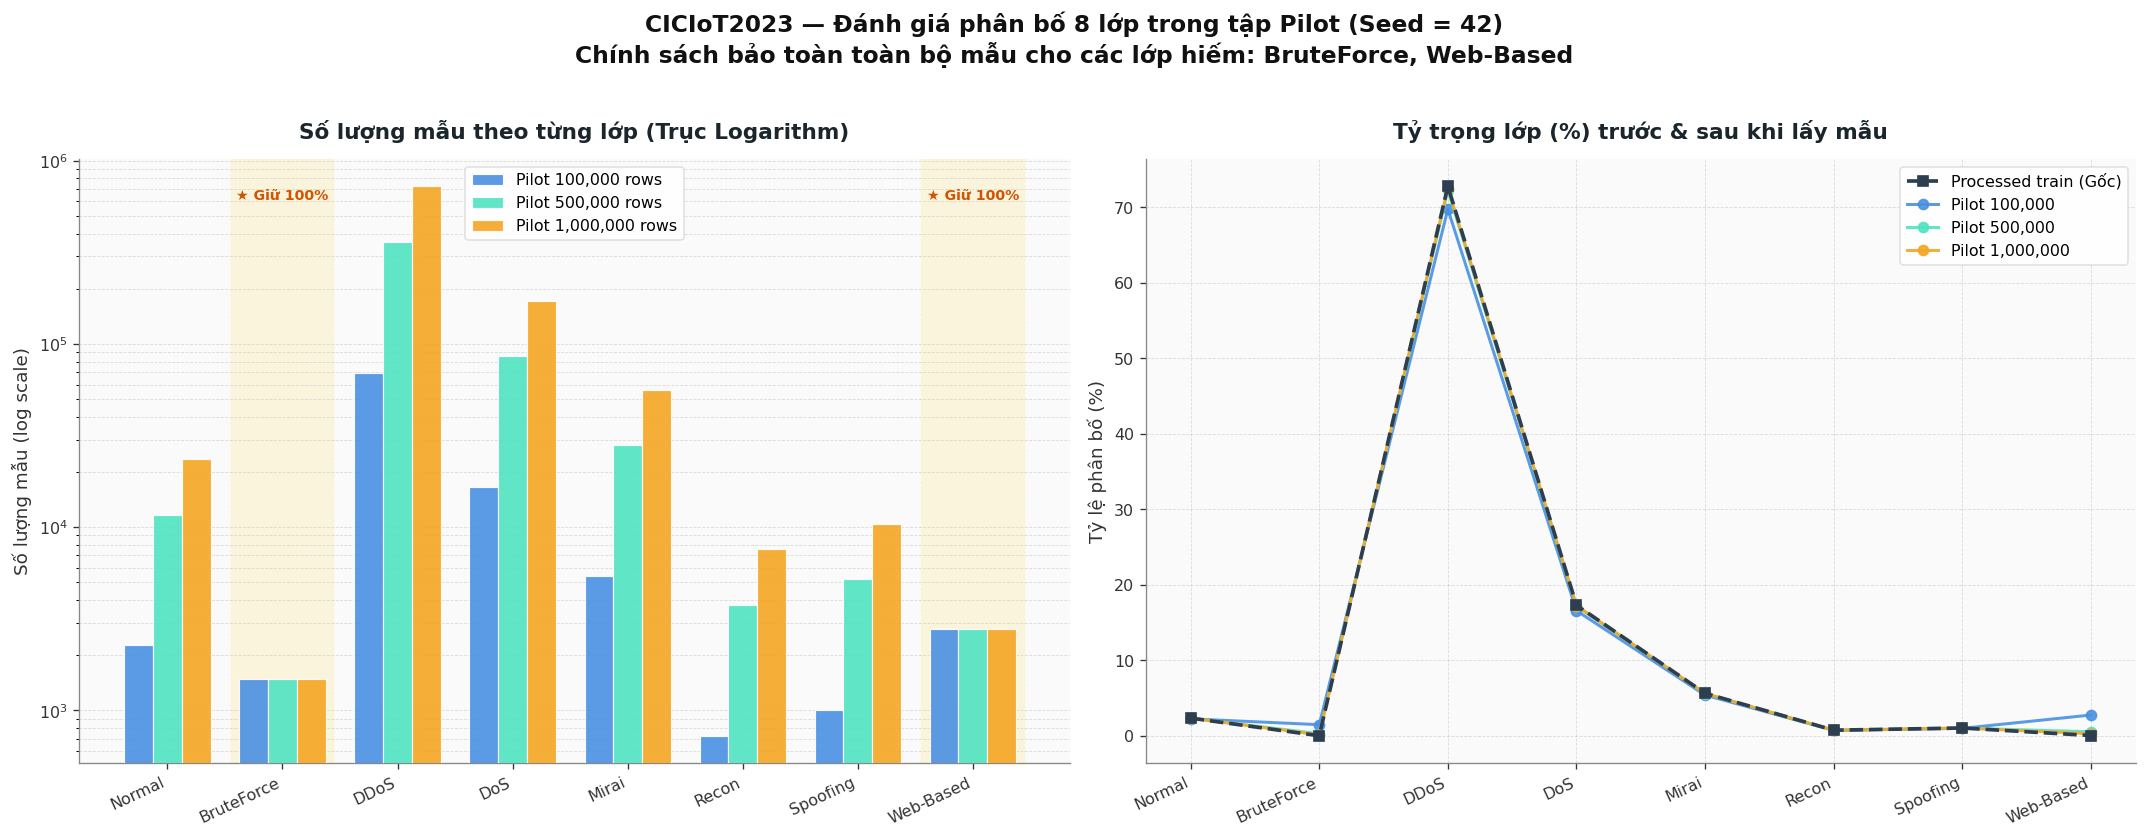

In [5]:
distribution_records = []
for budget in BUDGETS:
    counts = quotas_by_budget[budget]
    for class_id, name in enumerate(CLASS_NAMES):
        before_pct = float(source_counts[class_id] / N_TRAIN * 100)
        after_pct = float(counts[class_id] / budget * 100)
        distribution_records.append({
            "budget": budget, "class_id": class_id, "class_name": name,
            "source_train_count": int(source_counts[class_id]), "selected_count": int(counts[class_id]),
            "source_train_percent": before_pct, "pilot_percent": after_pct,
            "retained_percent": float(counts[class_id] / source_counts[class_id] * 100),
            "share_change_pp": after_pct - before_pct, "protected": class_id in protected_ids,
        })
distribution = pd.DataFrame(distribution_records)
display(distribution)
display(distribution.pivot(index="class_name", columns="budget", values="selected_count").reindex(CLASS_NAMES))

# Thiết lập phong cách hiển thị sạch và hiện đại
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.edgecolor'] = '#CCCCCC'
plt.rcParams['axes.linewidth'] = 0.8

fig, axes = plt.subplots(1, 2, figsize=(18, 6.8), dpi=120)

positions = np.arange(len(CLASS_NAMES))
n_budgets = len(BUDGETS)
width = 0.75 / n_budgets

# Palette màu trang nhã, phân biệt rõ các budget
budget_colors = ["#4A90E2", "#50E3C2", "#F5A623", "#9013FE"][:n_budgets]
source_color = "#2C3E50"

# -------------------------------------------------------------
# Subplot 1: Số lượng mẫu từng lớp (Log Scale)
# -------------------------------------------------------------
ax1 = axes[0]
for j, budget in enumerate(BUDGETS):
    offset = (j - (n_budgets - 1) / 2) * width
    ax1.bar(
        positions + offset,
        quotas_by_budget[budget],
        width,
        label=f"Pilot {budget:,} rows",
        color=budget_colors[j],
        edgecolor="white",
        linewidth=0.7,
        alpha=0.9,
        zorder=3
    )

ax1.set_yscale("log")
ax1.set_title("Số lượng mẫu theo từng lớp (Trục Logarithm)", fontsize=13, fontweight="bold", pad=12, color="#1A252C")
ax1.set_ylabel("Số lượng mẫu (log scale)", fontsize=11, fontweight="medium", color="#333333")
ax1.grid(axis="y", which="both", linestyle="--", linewidth=0.5, alpha=0.5, color="#BBBBBB", zorder=0)

# Highlight các lớp bảo vệ (thiểu số)
for class_name in PROTECTED_CLASSES:
    if class_name in CLASS_TO_ID:
        idx = CLASS_TO_ID[class_name]
        ax1.axvspan(idx - 0.45, idx + 0.45, color="#FFEAA7", alpha=0.35, zorder=1, linestyle=":")
        ax1.text(idx, 0.95, "★ Giữ 100%", transform=ax1.get_xaxis_transform(), ha="center", va="top",
                 fontsize=8.5, color="#D35400", fontweight="bold")

# -------------------------------------------------------------
# Subplot 2: Tỷ trọng phần trăm lớp trước vs sau lấy mẫu
# -------------------------------------------------------------
ax2 = axes[1]

# Đường tham chiếu Processed Train
ax2.plot(
    positions,
    source_counts / N_TRAIN * 100,
    color=source_color,
    linestyle="--",
    linewidth=2.2,
    marker="s",
    markersize=6,
    label="Processed train (Gốc)",
    zorder=4
)

for j, budget in enumerate(BUDGETS):
    percentages = quotas_by_budget[budget] / budget * 100
    ax2.plot(
        positions,
        percentages,
        color=budget_colors[j],
        linewidth=1.8,
        marker="o",
        markersize=6,
        label=f"Pilot {budget:,}",
        alpha=0.9,
        zorder=3
    )

ax2.set_title("Tỷ trọng lớp (%) trước & sau khi lấy mẫu", fontsize=13, fontweight="bold", pad=12, color="#1A252C")
ax2.set_ylabel("Tỷ lệ phân bố (%)", fontsize=11, fontweight="medium", color="#333333")
ax2.grid(axis="both", linestyle="--", linewidth=0.5, alpha=0.5, color="#BBBBBB", zorder=0)

# -------------------------------------------------------------
# Tinh chỉnh định dạng trục & Spines cho cả 2 Subplots
# -------------------------------------------------------------
for ax in axes:
    ax.set_xticks(positions)
    ax.set_xticklabels(CLASS_NAMES, rotation=25, ha="right", fontsize=10.5, fontweight="medium")
    ax.set_facecolor("#FAFAFA")
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#888888')
    ax.spines['bottom'].set_color('#888888')
    ax.tick_params(colors="#333333", labelsize=9.5)
    ax.legend(frameon=True, facecolor="white", edgecolor="#E0E0E0", framealpha=0.95, fontsize=9.5)

fig.suptitle(
    f"CICIoT2023 — Đánh giá phân bố 8 lớp trong tập Pilot (Seed = {RANDOM_STATE})\n"
    f"Chính sách bảo toàn toàn bộ mẫu cho các lớp hiếm: {', '.join(PROTECTED_CLASSES)}",
    fontsize=14,
    fontweight="bold",
    y=1.02,
    color="#111111"
)

fig.tight_layout()
plt.show()

## 6. Chuẩn bị thư mục output và tài liệu nguồn

Mỗi Run All tạo thư mục mới. Manifest ghi run processing nguồn, phiên bản thư viện, seed, quota và checksum của index. Hai ma trận feature có thể xuất sẵn hoặc tái tạo từ index; validation/test được tham chiếu về đúng run nguồn và không sao chép/lấy mẫu lại.

File `.npy` được đọc qua [NumPy mmap](https://numpy.org/doc/stable/reference/generated/numpy.load.html) và ghi theo batch bằng [open_memmap](https://numpy.org/doc/stable/reference/generated/numpy.lib.format.open_memmap.html) để hạn chế RAM.


In [6]:
PILOT_RUN_ID = "pilot_" + time.strftime("%Y%m%d_%H%M%S") + "_" + uuid.uuid4().hex[:8]
OUTPUT_ROOT = Path("/kaggle/working/pilot_data")
OUTPUT_DIR = OUTPUT_ROOT / PILOT_RUN_ID
OUTPUT_DIR.mkdir(parents=True, exist_ok=False)


def write_json(path, value):
    Path(path).write_text(json.dumps(value, ensure_ascii=False, indent=2, allow_nan=False), encoding="utf-8")


write_json(OUTPUT_DIR / "run_status.json", {"run_id": PILOT_RUN_ID, "status": "in_progress",
                                           "source_processing_run_id": processing["run_id"]})
plots_dir = OUTPUT_DIR / "plots"
plots_dir.mkdir()
fig.savefig(plots_dir / "pilot_class_distribution_8_classes.png", dpi=150, bbox_inches="tight")
plt.close(fig)
distribution.to_csv(OUTPUT_DIR / "class_distribution_all_budgets.csv", index=False)
reference_dir = OUTPUT_DIR / "source_reference"
reference_dir.mkdir()
reference_files = [
    "preprocessing_config.json", "feature_schema.json", "label_mapping.json",
    "source_manifest.json", "class_support_final.csv", "feature_names.txt", "run_status.json",
    processing["preprocessors"]["tree"], processing["preprocessors"]["scaled"],
]
reference_manifest = []
for filename in dict.fromkeys(reference_files):
    original = source_artifact(filename)
    destination = reference_dir / original.name
    shutil.copy2(original, destination)
    reference_manifest.append({"file": original.name, "sha256": sha256_file(destination), "bytes": destination.stat().st_size})
write_json(OUTPUT_DIR / "source_reference_manifest.json", reference_manifest)

heldout_reference = {
    "source_processing_run_id": processing["run_id"],
    "source_dir_at_pilot_creation": str(SOURCE_DIR),
    "resolution": "Reattach the same processed run; resolve its actual Kaggle path, then use relative filenames below.",
    "validation_policy": "same full processed validation for every budget/model",
    "test_policy": "final evaluation after choosing model and size; not used for pilot sampling",
    "splits": {split: INPUT_SPECS[split] for split in ["val", "test"]},
}
write_json(OUTPUT_DIR / "evaluation_reference.json", heldout_reference)
write_json(OUTPUT_DIR / "input_array_inventory.json", array_inventory)

estimated_feature_bytes = sum(BUDGETS) * len(FEATURE_NAMES) * (
    np.dtype(train_spec["raw_dtype"]).itemsize + np.dtype(train_spec["scaled_dtype"]).itemsize
) if EXPORT_FEATURE_ARRAYS else 0
free_bytes = shutil.disk_usage(OUTPUT_DIR).free
print("Output:", OUTPUT_DIR)
print(f"Dung lượng ma trận feature dự kiến: {estimated_feature_bytes / 1024**3:.2f} GiB")
if free_bytes < estimated_feature_bytes + 256 * 1024**2:
    raise OSError("Thiếu dung lượng trống; tắt EXPORT_FEATURE_ARRAYS hoặc giảm BUDGETS rồi Restart/Run All.")


Output: /kaggle/working/pilot_data/pilot_20261008_022915_ea9a88b0
Dung lượng ma trận feature dự kiến: 0.79 GiB


## 7. Xuất index, nhãn, metadata và hai nhánh X

`train_indices.npy` là vị trí dòng trong **processed train của run nguồn**, không phải dòng trong CSV gốc. `source_row_indices.npy` là dòng CSV gốc; sample ID đầy đủ là `train:<source_row_index>`. Tất cả file trong một budget dùng cùng thứ tự hàng.

Các kiểm tra tại đây chạy trên Kaggle: đủ số hàng/8 lớp, giữ lớp bảo vệ, không lặp ID, lồng nhau, nhãn khớp metadata, giá trị feature hữu hạn và dữ liệu ghi đọc lại khớp theo batch. Chưa chạy mô hình ở bước này.


In [7]:
def export_feature_subset(source_path, indices, destination):
    source = np.load(source_path, mmap_mode="r", allow_pickle=False)
    expected_shape = (len(indices), source.shape[1])
    output = np.lib.format.open_memmap(destination, mode="w+", dtype=source.dtype, shape=expected_shape)
    for start in range(0, len(indices), EXPORT_BATCH_SIZE):
        stop = min(start + EXPORT_BATCH_SIZE, len(indices))
        block = np.asarray(source[indices[start:stop]])
        if not np.isfinite(block).all():
            raise ValueError(f"NaN/Inf trong {Path(source_path).name}, batch {start}:{stop}.")
        output[start:stop] = block
    output.flush()
    del output
    saved = np.load(destination, mmap_mode="r", allow_pickle=False)
    if saved.shape != expected_shape or saved.dtype != source.dtype:
        raise RuntimeError("Shape/dtype output không khớp nguồn.")
    for start in range(0, len(indices), EXPORT_BATCH_SIZE):
        stop = min(start + EXPORT_BATCH_SIZE, len(indices))
        if not np.array_equal(saved[start:stop], source[indices[start:stop]]):
            raise RuntimeError(f"Nội dung output không khớp index: {destination}")
    dtype = str(saved.dtype)
    del saved, source
    return {"file": Path(destination).name, "shape": list(expected_shape), "dtype": dtype,
            "bytes": Path(destination).stat().st_size, "sha256": sha256_file(destination),
            "batch_values_match_source": True}


budget_manifests = []
for budget in BUDGETS:
    started = time.perf_counter()
    folder = OUTPUT_DIR / f"train_{budget}"
    folder.mkdir()
    indices = selected_indices[budget]
    labels = np.asarray(y_train[indices]).copy()
    selected_meta = train_metadata.iloc[indices].copy().reset_index(drop=True)
    selected_meta.insert(0, "processed_train_row_index", indices)
    if not np.array_equal(selected_meta["class_id"].to_numpy(), labels):
        raise RuntimeError("Nhãn và metadata pilot lệch thứ tự.")
    raw_rows = selected_meta["source_row_index"].to_numpy(dtype=np.int64)
    if np.unique(raw_rows).size != budget:
        raise RuntimeError("Pilot có source row ID trùng.")
    np.save(folder / "train_indices.npy", indices, allow_pickle=False)
    np.save(folder / "source_row_indices.npy", raw_rows, allow_pickle=False)
    np.save(folder / "y_train.npy", labels, allow_pickle=False)
    pd.Series(labels, name="class_id").to_pickle(folder / "y_train.pkl")
    selected_meta.to_pickle(folder / "sample_metadata_train.pkl")
    support = distribution.loc[distribution["budget"] == budget].copy()
    support.to_csv(folder / "class_support.csv", index=False)
    if not np.array_equal(np.load(folder / "train_indices.npy", allow_pickle=False), indices):
        raise RuntimeError("Index ghi ra không khớp.")
    if not np.array_equal(np.load(folder / "y_train.npy", allow_pickle=False), labels):
        raise RuntimeError("Nhãn ghi ra không khớp.")

    features = {}
    if EXPORT_FEATURE_ARRAYS:
        for view, key in [("raw", "raw_file"), ("scaled", "scaled_file")]:
            features[view] = export_feature_subset(
                source_artifact(train_spec[key]), indices, folder / f"X_train_{view}.npy"
            )
    provenance_files = ["train_indices.npy", "source_row_indices.npy", "y_train.npy", "y_train.pkl", "sample_metadata_train.pkl"]
    checksums = {name: sha256_file(folder / name) for name in provenance_files}
    manifest = {
        "pilot_run_id": PILOT_RUN_ID, "source_processing_run_id": processing["run_id"],
        "budget": budget, "seed": RANDOM_STATE, "class_names": CLASS_NAMES, "class_to_id": CLASS_TO_ID,
        "feature_names": FEATURE_NAMES, "num_features": len(FEATURE_NAMES),
        "class_support": {name: int(quotas_by_budget[budget][i]) for i, name in enumerate(CLASS_NAMES)},
        "protected_classes": PROTECTED_CLASSES, "minimum_per_other_class": MIN_PER_OTHER_CLASS,
        "selection_policy": "all protected-class rows; proportional incremental quotas from remaining rows; seeded per-class permutations",
        "nested_budgets": BUDGETS, "replacement": False, "row_order": "ascending processed_train_row_index",
        "indices_file": "train_indices.npy", "indices_coordinate_system": "0-based row position in source processed train",
        "source_rows_file": "source_row_indices.npy", "sample_id_format": "train:<source_row_index>",
        "target_file": "y_train.npy", "metadata_file": "sample_metadata_train.pkl",
        "features_exported": EXPORT_FEATURE_ARRAYS, "features": features, "checksums_sha256": checksums,
        "preprocessing_policy": "reuse fixed preprocessing fitted on full source train; no refit on each pilot",
        "evaluation_reference": "../evaluation_reference.json",
        "status": "complete", "export_and_validation_seconds": round(time.perf_counter() - started, 3),
    }
    write_json(folder / "pilot_manifest.json", manifest)
    budget_manifests.append({"budget": budget, "directory": folder.name,
                             "manifest": f"{folder.name}/pilot_manifest.json",
                             "indices_sha256": checksums["train_indices.npy"],
                             "class_support": manifest["class_support"]})
    print(f"Đã xuất {budget:,} dòng; raw/scaled={EXPORT_FEATURE_ARRAYS}; {manifest['export_and_validation_seconds']:.2f}s")
    del labels, selected_meta, raw_rows, support
    gc.collect()


Đã xuất 100,000 dòng; raw/scaled=True; 62.82s
Đã xuất 500,000 dòng; raw/scaled=True; 3.92s
Đã xuất 1,000,000 dòng; raw/scaled=True; 5.18s


## 8. Tài liệu bàn giao và mẫu ghi kết quả mô hình

Bảng benchmark được tạo rỗng với trạng thái `not_run`, dành cho thành viên làm mô hình cập nhật sau khi huấn luyện trên Kaggle. Số đo xuất dữ liệu ở notebook này không phải thời gian huấn luyện.


In [8]:
benchmark_rows = []
for budget in BUDGETS:
    for model, view in [("LogisticRegression", "scaled"), ("DecisionTree", "raw"), ("RandomForest", "raw")]:
        row = {
            "pilot_run_id": PILOT_RUN_ID, "source_processing_run_id": processing["run_id"],
            "train_budget": budget, "model": model, "input_view": view,
            "sampling_seed": RANDOM_STATE, "model_seed": None,
            "model_config_id": None, "model_run_id": None,
            "fit_seconds": None, "predict_seconds": None, "peak_ram_mib": None,
            "validation_rows": INPUT_SPECS["val"]["shape"][0],
            "val_macro_f1": None, "val_weighted_f1": None, "val_accuracy": None,
            "status": "not_run",
        }
        for name in CLASS_NAMES:
            row[f"val_recall_{name}"] = None
            row[f"val_f1_{name}"] = None
        benchmark_rows.append(row)
pd.DataFrame(benchmark_rows).to_csv(OUTPUT_DIR / "benchmark_template.csv", index=False)

handoff = f"""# Bàn giao pilot CICIoT2023 — 8 lớp

- Pilot run: `{PILOT_RUN_ID}`.
- Processing nguồn: `{processing['run_id']}`.
- Seed lấy mẫu: `{RANDOM_STATE}`; budgets: `{BUDGETS}`.
- Giữ toàn bộ lớp: `{PROTECTED_CLASSES}`; tất cả tập con đủ 8 lớp, không lấy lặp ID.
- Preprocessing dùng chung bộ đã fit trên toàn train nguồn. Đây là so sánh quy mô huấn luyện classifier với preprocessing cố định.
- Feature order/mapping: `source_reference/feature_schema.json` và `source_reference/label_mapping.json`.

## File cho từng budget

Mỗi `train_<budget>/` có index, nhãn, source-row ID, sample metadata, bảng support và manifest. `X_train_raw.npy`/`X_train_scaled.npy` được xuất khi `EXPORT_FEATURE_ARRAYS=True` (lần này: `{EXPORT_FEATURE_ARRAYS}`). Nếu chỉ xuất index, đọc source train qua mmap rồi chọn đúng `train_indices.npy` theo batch.

Raw là dữ liệu đã chọn cột/điền thiếu, giữ thang gốc. Scaled đã áp dụng log/scale. Khi train trực tiếp trên các file này, không transform thêm lần nữa. Khi suy luận từ feature CSV gốc, dùng transformer tương ứng trong `source_reference/` cùng model đã huấn luyện; dùng phiên bản thư viện của processing config khi nạp joblib.

## Validation và test

Gắn lại bộ processed nguồn cùng output pilot trong notebook huấn luyện. Dùng `evaluation_reference.json` để lấy tên file tương đối; tìm lại đường dẫn Kaggle thực sau khi gắn dataset. Giữ cùng validation cho mọi budget/model. Test dùng cuối, sau khi chốt model và quy mô. Phân bố evaluation là bộ đã qua `purge_eval` của run nguồn.

## Cách quyết định quy mô train

1. Chạy cùng một protocol ở từng budget; ghi model seed, cấu hình và phần cứng.
2. Điền `benchmark_template.csv` bằng kết quả thực. Ghi precision/recall/F1/support đủ 8 lớp và confusion matrix 8×8 trong báo cáo mô hình.
3. So sánh macro-F1 cùng recall/F1 các lớp hiếm trên cùng validation; xem thêm thời gian và RAM. Không suy ra 100k hay 1M là tốt nhất trước khi chạy.
4. Giữ các quyết định xử lý mất cân bằng nhất quán khi so sánh quy mô; nếu thay class_weight hoặc thuật toán, ghi thành thí nghiệm riêng.
5. Cả ba tập đều giữ toàn bộ BruteForce/Web-Based hiện có; tăng budget chủ yếu bổ sung các lớp khác. Các tập không độc lập với nhau vì được thiết kế lồng nhau.

Các ô metric trống là chưa huấn luyện, không phải điểm 0. Notebook lấy mẫu chưa hoàn thành việc lựa chọn quy mô chính thức cho TV1-03.
"""
(OUTPUT_DIR / "README_HANDOFF.md").write_text(handoff, encoding="utf-8")
print("Đã tạo README_HANDOFF.md và benchmark_template.csv (chưa có số đo mô hình).")


Đã tạo README_HANDOFF.md và benchmark_template.csv (chưa có số đo mô hình).


## 9. Xác nhận hoàn tất bộ pilot


In [10]:
# Kiểm tra lại quan hệ lồng nhau từ các index đã lưu.
previous_saved = None
for budget in BUDGETS:
    folder = OUTPUT_DIR / f"train_{budget}"
    saved_indices = np.load(folder / "train_indices.npy", allow_pickle=False)
    saved_y = np.load(folder / "y_train.npy", allow_pickle=False)
    if saved_indices.shape != (budget,) or not np.array_equal(saved_y, y_train[saved_indices]):
        raise RuntimeError("Bộ index/y cuối không khớp train nguồn.")
    if previous_saved is not None:
        locations = np.searchsorted(saved_indices, previous_saved)
        if (locations >= len(saved_indices)).any() or not np.array_equal(saved_indices[locations], previous_saved):
            raise RuntimeError("Index ghi ra không giữ tính lồng nhau.")
    previous_saved = saved_indices

root_manifest = {
    "pilot_run_id": PILOT_RUN_ID, "source_processing_run_id": processing["run_id"],
    "source_dir_at_creation": str(SOURCE_DIR), "seed": RANDOM_STATE, "budgets": BUDGETS,
    "protected_classes": PROTECTED_CLASSES, "source_train_rows": N_TRAIN,
    "source_train_support": {name: int(source_counts[i]) for i, name in enumerate(CLASS_NAMES)},
    "source_config_sha256": sha256_file(SOURCE_DIR / "preprocessing_config.json"),
    "source_y_train_sha256": sha256_file(source_artifact(train_spec["target_file"])),
    "large_source_feature_checks": "NPY shape/dtype/size plus selected-row export equality; no full input matrix hash",
    "feature_arrays_exported": EXPORT_FEATURE_ARRAYS, "pilots": budget_manifests,
    "class_names": CLASS_NAMES, "class_to_id": CLASS_TO_ID, "feature_names": FEATURE_NAMES,
    "preprocessing_fit_scope": "full source train, fixed across budgets",
    "evaluation_reference": "evaluation_reference.json", "source_reference": "source_reference/",
    "sampling_seconds": sampling_seconds, "total_seconds": round(time.perf_counter() - STARTED, 3),
    "versions": {"python": platform.python_version(), "numpy": np.__version__, "pandas": pd.__version__},
    "checks": {"exact_budgets": True, "all_8_classes": True, "protected_classes_all_kept": True,
               "unique_processed_row_ids": True, "nested_saved_indices": True,
               "labels_match_metadata": True, "features_equal_source_at_indices": EXPORT_FEATURE_ARRAYS},
    "model_training_status": "not_run", "status": "complete",
}
write_json(OUTPUT_DIR / "pilot_manifest.json", root_manifest)
write_json(OUTPUT_DIR / "run_status.json", {
    "run_id": PILOT_RUN_ID, "source_processing_run_id": processing["run_id"], "status": "complete",
    "finished_at": time.strftime("%Y-%m-%d %H:%M:%S"), "total_seconds": root_manifest["total_seconds"],
})
write_json(OUTPUT_ROOT / "latest_pilot_run.json", {"run_id": PILOT_RUN_ID, "path": str(OUTPUT_DIR), "status": "complete"})
print("HOÀN TẤT TẠO DỮ LIỆU PILOT:", OUTPUT_DIR)
print("Budgets:", BUDGETS, "| Đủ 8 lớp | Seed:", RANDOM_STATE)
print("Đã giữ toàn bộ:", {name: int(source_counts[CLASS_TO_ID[name]]) for name in PROTECTED_CLASSES})
print("Validation/test tham chiếu cùng run nguồn; chưa huấn luyện/chọn model.")
print("Bàn giao toàn bộ thư mục này và gắn lại processed_data trong notebook huấn luyện.")
display(distribution.pivot(index="class_name", columns="budget", values="selected_count").reindex(CLASS_NAMES))


HOÀN TẤT TẠO DỮ LIỆU PILOT: /kaggle/working/pilot_data/pilot_20261008_022915_ea9a88b0
Budgets: [100000, 500000, 1000000] | Đủ 8 lớp | Seed: 42
Đã giữ toàn bộ: {'BruteForce': 1488, 'Web-Based': 2768}
Validation/test tham chiếu cùng run nguồn; chưa huấn luyện/chọn model.
Bàn giao toàn bộ thư mục này và gắn lại processed_data trong notebook huấn luyện.


budget,100000,500000,1000000
class_name,,,
Normal,2261,11705,23511
BruteForce,1488,1488,1488
DDoS,69761,361224,725553
DoS,16584,85867,172471
Mirai,5407,27993,56225
Recon,727,3759,7549
Spoofing,1004,5196,10435
Web-Based,2768,2768,2768
